# Possum regession - advanced notebook

**Database source:** https://www.kaggle.com/datasets/abrambeyer/openintro-possum

**Database description:** The possum data frame consists of nine morphometric measurements on each of 104 mountain brushtail possums, trapped at seven sites from Southern Victoria to central Queensland.

**Dataset columns:**
- `case` - observation number
- `site` - the site number, where the possum was trapped
- `Pop` - population, either Vic (Victoria) or other (New South Wales or Queensland)
- `sex` - gender, either m (male) or f (female)
- `age` - age
- `hdlngth` - head length (mm)
- `skullw` - skull width (mm)
- `totlngth` - total length (cm)
- `taill` - tail length (cm)
- `footlgth` - foot length (mm)
- `earconch` - ear conch length (mm)
- `eye` - distance from medial canthus to lateral canthus of right eye (mm)
- `chest` - chest girth (cm)
- `belly` - belly girth (cm)


## Data preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

possum_df = pd.read_csv('possum.csv')

In [2]:
possum_df.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


### Check for missing data

In [3]:
possum_df.isna().sum()

case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64

### Imputing missing values

In [4]:
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
possum_df[['age', 'footlgth']] = imputer.fit_transform(possum_df[['age', 'footlgth']])

In [5]:
possum_df.isna().sum()

case        0
site        0
Pop         0
sex         0
age         0
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    0
earconch    0
eye         0
chest       0
belly       0
dtype: int64

### Prepare data for analysis

In [6]:
# Change sex variables to numerical

possum_df['sex'] = [1 if i == 'm' else 0 for i in possum_df['sex']]

### Data breakdown

In [7]:
possum_df.describe()

,case,site,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,3.625000,0.586538,3.833333,92.602885,56.883654,87.088462,37.009615,68.459223,48.130769,15.046154,27.000000,32.586538
std,30.166206,2.349086,0.494839,1.890617,3.573349,3.113426,4.310549,1.959518,4.373917,4.109380,1.050374,2.045597,2.761949
min,1.000000,1.000000,0.000000,1.000000,82.500000,50.000000,75.000000,32.000000,60.300000,40.300000,12.800000,22.000000,25.000000
25%,26.750000,1.000000,0.000000,2.750000,90.675000,54.975000,84.000000,35.875000,64.650000,44.800000,14.400000,25.500000,31.000000
50%,52.500000,3.000000,1.000000,3.000000,92.800000,56.350000,88.000000,37.000000,68.100000,46.800000,14.900000,27.000000,32.500000
75%,78.250000,6.000000,1.000000,5.000000,94.725000,58.100000,90.000000,38.000000,72.500000,52.000000,15.725000,28.000000,34.125000
max,104.000000,7.000000,1.000000,9.000000,103.100000,68.600000,96.500000,43.000000,77.900000,56.200000,17.800000,32.000000,40.000000


In [8]:
numeric_df = possum_df.select_dtypes(include='number')
print(numeric_df.corr())

              case      site       sex       age   hdlngth    skullw  \
case      1.000000  0.970353  0.253980 -0.194404 -0.209177 -0.125065   
site      0.970353  1.000000  0.232817 -0.130799 -0.163646 -0.083548   
sex       0.253980  0.232817  1.000000 -0.063995  0.107200  0.080014   
age      -0.194404 -0.130799 -0.063995  1.000000  0.311848  0.279955   
hdlngth  -0.209177 -0.163646  0.107200  0.311848  1.000000  0.710827   
skullw   -0.125065 -0.083548  0.080014  0.279955  0.710827  1.000000   
totlngth -0.334329 -0.260843 -0.160200  0.250970  0.691094  0.526413   
taill     0.315351  0.380444 -0.040917  0.117274  0.287429  0.255921   
footlgth -0.781811 -0.781171 -0.122964  0.125314  0.388941  0.275057   
earconch -0.773727 -0.790716 -0.091559  0.052943  0.121463 -0.000537   
eye      -0.084078 -0.036987  0.188371  0.234669  0.347175  0.321991   
chest    -0.402303 -0.345494 -0.139074  0.325303  0.631498  0.629737   
belly    -0.211671 -0.175266 -0.090777  0.345825  0.562663  0.45

## Prediction of head length based on total length categorized by sex

C:\Users\wikto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\wikto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


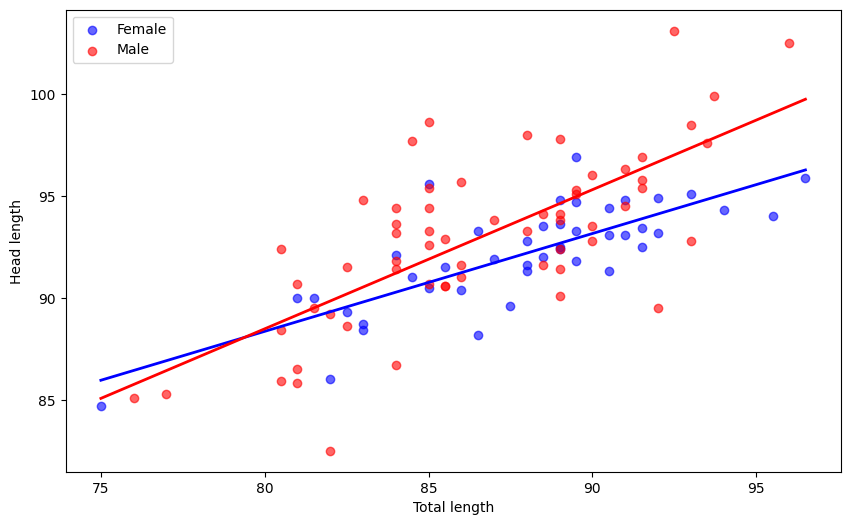

Female model: 
Intercept (b):  49.97455443350533
Coefficient (a):  0.4797603596188547

Male model: 
Intercept (b):  33.8824674838616
Coefficient (a):  0.6824584028432583


In [9]:
females = possum_df[possum_df.sex == 0]
males = possum_df[possum_df.sex == 1]

model_f = LinearRegression()
model_m = LinearRegression()

X_f = females[['totlngth']]
y_f = females['hdlngth']
X_m = males[['totlngth']]
y_m = males['hdlngth']

model_f.fit(X_f, y_f)
model_m.fit(X_m, y_m)

x_range = np.linspace(possum_df.totlngth.min(), possum_df.totlngth.max(), 100).reshape(-1, 1)
y_pred_f = model_f.predict(x_range)
y_pred_m = model_m.predict(x_range)

plt.figure(figsize=(10,6))
plt.scatter(X_f, y_f, color='blue', alpha=0.6, label='Female')
plt.scatter(X_m, y_m, color='red', alpha=0.6, label='Male')
plt.plot(x_range, y_pred_f, color='blue', linewidth=2)
plt.plot(x_range, y_pred_m, color='red', linewidth=2)
plt.xlabel("Total length")
plt.ylabel("Head length")
plt.legend()
plt.show()

print("Female model: ")
print("Intercept (b): ", model_f.intercept_)
print("Coefficient (a): ", model_f.coef_[0])

print("\nMale model: ")
print("Intercept (b): ", model_m.intercept_)
print("Coefficient (a): ", model_m.coef_[0])

The red line (males) has a larger coefficient, which means that head length in male possums increases faster with total length compared to females. This indicates that males show a stronger correlation between head length and total length.

The blue line (females) is slightly lower than the male line, suggesting that female possums have, on average, shorter heads than males of similar total length.

## Prediction of ear conch length based on foot length categorized by sex

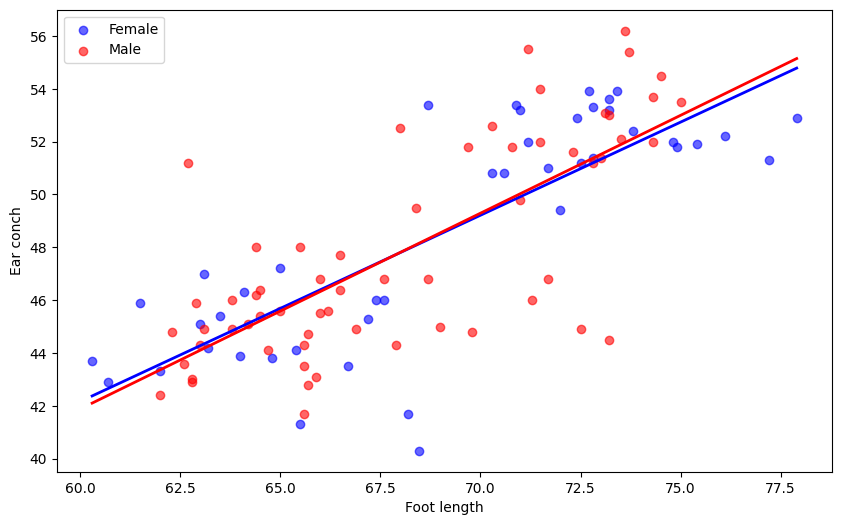

Female model:
Intercept (b): -0.1512659261434166
Coefficient (a): 0.7052144558231633

Male model:
Intercept (b): -2.589017700423483
Coefficient (a): 0.7411488405066367


In [10]:
females = possum_df[possum_df.sex == 0]
males = possum_df[possum_df.sex == 1]

model_f = LinearRegression()
model_m = LinearRegression()

X_f = females[['footlgth']]
y_f = females['earconch']
X_m = males[['footlgth']]
y_m = males['earconch']

model_f.fit(X_f, y_f)
model_m.fit(X_m, y_m)

x_range = np.linspace(possum_df.footlgth.min(), possum_df.footlgth.max(), 100).reshape(-1, 1)
x_range_df = pd.DataFrame(x_range, columns=['footlgth'])

y_pred_f = model_f.predict(x_range_df)
y_pred_m = model_m.predict(x_range_df)

plt.figure(figsize=(10,6))
plt.scatter(X_f, y_f, color='blue', alpha=0.6, label='Female')
plt.scatter(X_m, y_m, color='red', alpha=0.6, label='Male')
plt.plot(x_range, y_pred_f, color='blue', linewidth=2)
plt.plot(x_range, y_pred_m, color='red', linewidth=2)
plt.xlabel("Foot length")
plt.ylabel("Ear conch")
plt.legend()
plt.show()

print("Female model:")
print("Intercept (b):", model_f.intercept_)
print("Coefficient (a):", model_f.coef_[0])

print("\nMale model:")
print("Intercept (b):", model_m.intercept_)
print("Coefficient (a):", model_m.coef_[0])

The red line (males) has a slightly steeper slope and a larger coefficient, indicating that males show a somewhat stronger relationship between foot length and ear conch. However, the difference between the two groups is not substantial.

The blue line (females) lies slightly below the male line, suggesting that male possums tend to have, on average, longer ears than females with the same foot length.

## Logistic regression - sex vs total length

Although it's name it is not a regression, but classification problem. It predicts probability that an input belongs to a specific class. It is used for binary classification where the output can be one of two possible categories: in our case male/female (1/0).

R²: 0.53125
Intercept (b): [10.68536599]
Coefficient (a): [[-0.11754014]]
Mean squared error:  0.46875


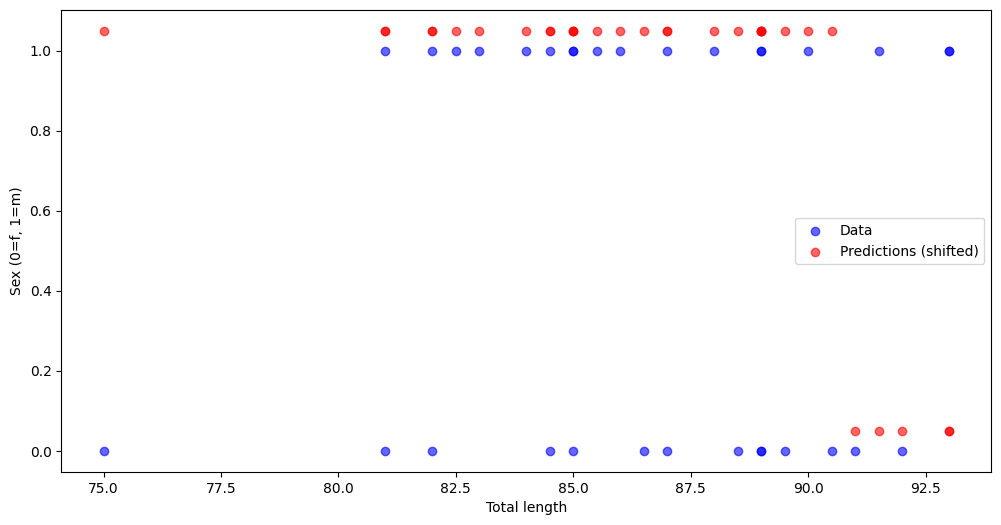

In [11]:
X = possum_df['totlngth'].values.reshape(-1, 1)
y = possum_df['sex'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=44)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = model.score(X_test, y_test)
print("R²:", r2)

print("Intercept (b):", model.intercept_)
print("Coefficient (a):", model.coef_)

mse = mean_squared_error(y_test, y_pred)
print("Mean squared error: ", mse)

plt.figure(figsize=(12,6))
plt.scatter(X_test, y_test, color = "blue", alpha = 0.6, label="Data")
plt.scatter(X_test, y_pred + 0.05, color='red', alpha = 0.6, label='Predictions (shifted)')
plt.xlabel("Total length")
plt.ylabel("Sex (0=f, 1=m)")
plt.legend()
plt.show()

Predictions were slightly shifted vertically so they won't overleap each other. It helps with plot interpretation. The prediction dots (red) that are directly above data dots (blue) mean that the possum's sex was predicted correctly. Single blue and single red dots are misclassifications.

In [12]:
print(np.unique(y_test, return_counts=True))
np.unique(y_pred, return_counts=True)

(array([0, 1]), array([14, 18]))


(array([0, 1]), array([ 5, 27]))

First output means that in the test data there were 14 females and 18 males.

Second output indicates that model predicted 5 females and 27 males.

We can see that model correctly predicted most of the males (`y=1`), since red dots with blue ones at the top.

Moreover model predicts mostly males since most of the red dots are on top.

At the bottom (`y=0`) we can see that model predicted only 2 females correctly so below medium of all female predictions.

This indicates that total length data is not enough to determine opossum's sex.

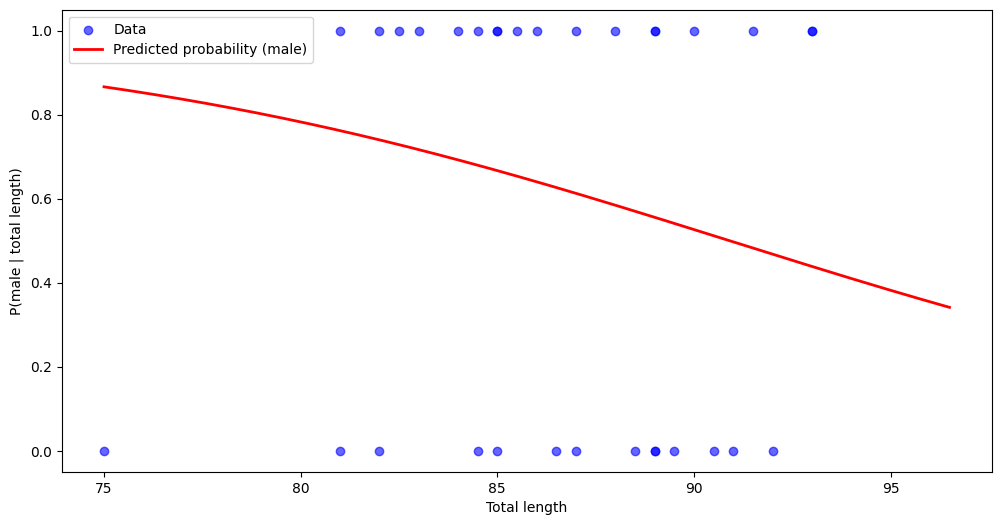

In [13]:
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

y_prob = model.predict_proba(X_range)[:, 1]

plt.figure(figsize=(12,6))
plt.scatter(X_test, y_test, color="blue", alpha=0.6, label="Data")
plt.plot(X_range, y_prob, color="red", linewidth=2, label="Predicted probability (male)")
plt.xlabel("Total length")
plt.ylabel("P(male | total length)")
plt.legend()
plt.show()

This plot shows the probablity of opossum being a male based on total body length calculated using logistic regression. The longer animal is, the probabilty decreases.

## Can we predict skull width based on head length?

### Data preparation

In [14]:
X = possum_df.hdlngth.values.reshape(-1,1)
y = possum_df.skullw.values

### Polynomial regressions of different degrees

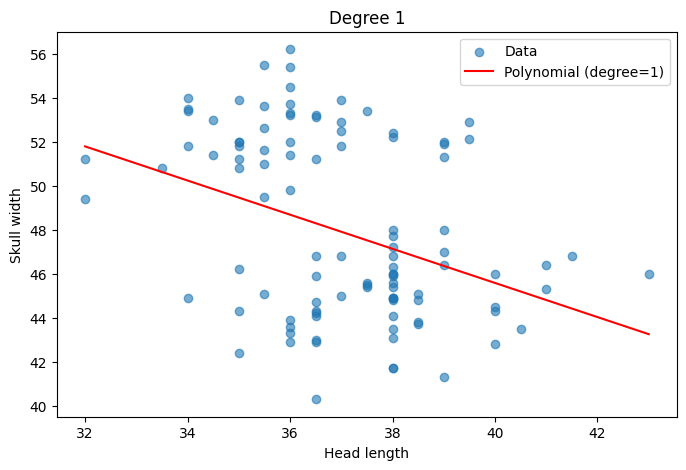

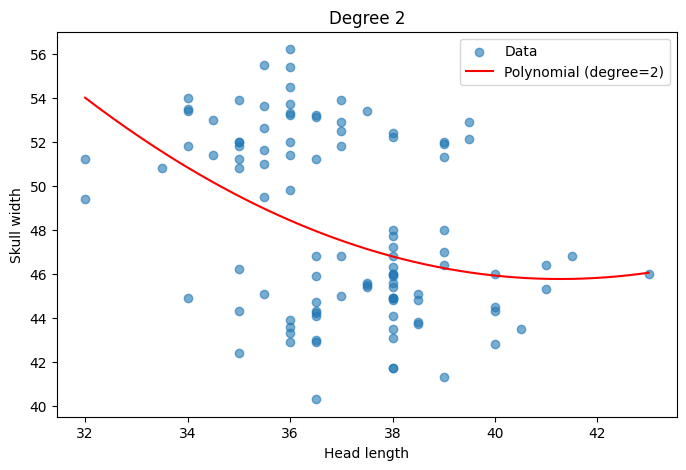

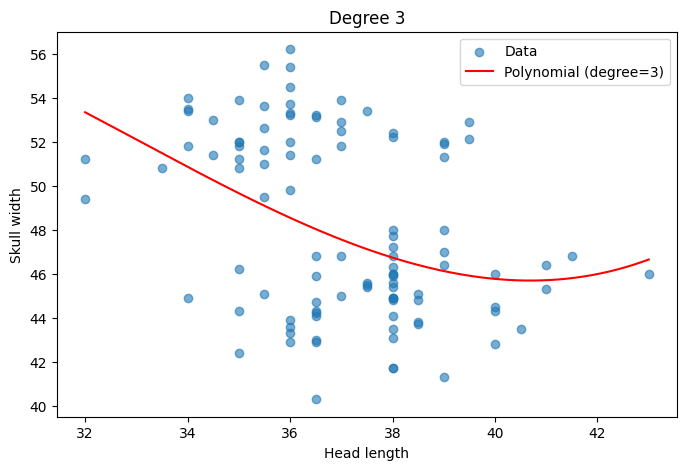

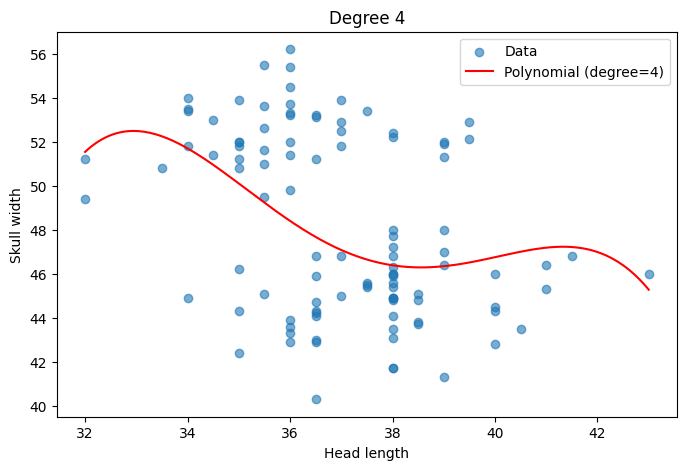

MSE error (degree 1): 15.320658955684543
MSE error (degree 2): 15.670816656885348
MSE error (degree 3): 15.41320267537989
MSE error (degree 4): 15.423013424421896


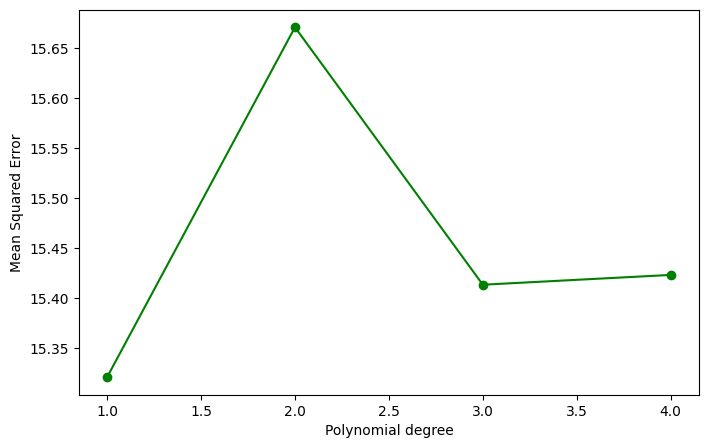

In [24]:
errors = []
degrees = [1, 2, 3, 4]

for degree in degrees:
    poly = PolynomialFeatures(degree, include_bias=False)
    X_degree = poly.fit_transform(X)

    X_train, X_test, y_train, y_test, X_orig_train, X_orig_test = train_test_split(
        X_degree, y, X, test_size=0.5, random_state=44
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    error = mean_squared_error(y_test, y_pred)
    errors.append(error)

    X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    X_plot_poly = poly.transform(X_plot)
    y_plot = model.predict(X_plot_poly)

    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, label="Data", alpha=0.6)
    plt.plot(X_plot, y_plot, color='red', label=f"Polynomial (degree={degree})")
    plt.title(f'Degree {degree}')
    plt.xlabel('Head length')
    plt.ylabel('Skull width')
    plt.legend()
    plt.show()

for degree, error in zip(degrees, errors):
    print(f"MSE error (degree {degree}): {error}")

plt.figure(figsize=(8, 5))
plt.plot(degrees, errors, marker='o', color='green')
plt.xlabel("Polynomial degree")
plt.ylabel("Mean Squared Error")
plt.show()

### Summary

The lowest MSE is obtained for the linear model (degree 1), confirming that the relationship between head length and skull width is essentially linear.

The longer a possum’s head is, the wider its skull tends to be.

Higher-degree polynomial models slightly increase the error, indicating that adding complexity does not improve prediction accuracy.

## Can we predict possum's age based on its body dimensions?


In [68]:
body_dimensions  = ['hdlngth', 'skullw', 'totlngth', 'taill', 
                    'footlgth', 'earconch', 'eye', 'chest', 'belly']

### Linear regression

In [69]:
X = possum_df[body_dimensions].values
y = possum_df['age'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=44)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = model.score(X_test, y_test)
print("R²:", r2)

mse = mean_squared_error(y_test, y_pred)
print("Mean squared error: ", mse)

R²: 0.012453167962762968
Mean squared error:  3.332970558125675


### Polynomial regression

In [70]:
X = possum_df[body_dimensions].values
y = possum_df.age.values.reshape(-1)

degrees = [1, 2, 3, 4, 5, 6]

for degree in degrees:
    poly = PolynomialFeatures(degree, include_bias=False)
    X_poly = poly.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_poly, y, test_size=0.5, random_state=44
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = model.score(X_test, y_test)

    print("--- Degree: ", degree, " ---")
    print("MSE: ", mse)
    print("R²: ", r2, "\n")


--- Degree:  1  ---
MSE:  4.065148616144679
R²:  -0.21701289197455864 

--- Degree:  2  ---
MSE:  303.4498488331431
R²:  -89.84597218192395 

--- Degree:  3  ---
MSE:  105.52190645031793
R²:  -30.590855012224168 



--- Degree:  4  ---
MSE:  74.55624524736115
R²:  -21.32044144287839 

--- Degree:  5  ---
MSE:  58.28301355338085
R²:  -16.448606576372207 

--- Degree:  6  ---
MSE:  48.43375857091916
R²:  -13.499963999715689 



The linear regression model achieved R² = 0.012 and MSE = 3.33, indicating that body dimensions explain almost none of the variability in possum age.

Polynomial models of degrees 2–6 produced strongly negative R² values and much higher MSE, confirming severe overfitting.

Therefore, increasing model complexity does not improve performance, and body measurements alone are insufficient predictors of age in this dataset.

## Can we use body measurements to predict head length?

In [71]:
body_dimensions2  = ['skullw', 'totlngth', 'taill', 
                    'footlgth', 'earconch', 'eye', 'chest', 'belly']

### Linear regression

In [72]:
X = possum_df[body_dimensions2].values
y = possum_df['hdlngth'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=44)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = model.score(X_test, y_test)
print("R²:", r2)

mse = mean_squared_error(y_test, y_pred)
print("Mean squared error: ", mse)

R²: 0.5199874697396139
Mean squared error:  6.02235720777937


### Ridge regression with regularization penalty

In [73]:
possum_df = possum_df.dropna(subset=body_dimensions2 + ['hdlngth'])

X = possum_df[body_dimensions2].values
y = possum_df['hdlngth'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=44)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = [0.01, 0.1, 1, 10, 100, 1000]

r2_scores = []
mses = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    r2_scores.append(r2)
    mses.append(mse)

    print(f"alpha={a:<6} | R²={r2:.3f} | MSE={mse:.3f}")

alpha=0.01   | R²=0.520 | MSE=6.022
alpha=0.1    | R²=0.520 | MSE=6.017
alpha=1      | R²=0.524 | MSE=5.973
alpha=10     | R²=0.534 | MSE=5.841
alpha=100    | R²=0.477 | MSE=6.562
alpha=1000   | R²=0.175 | MSE=10.357


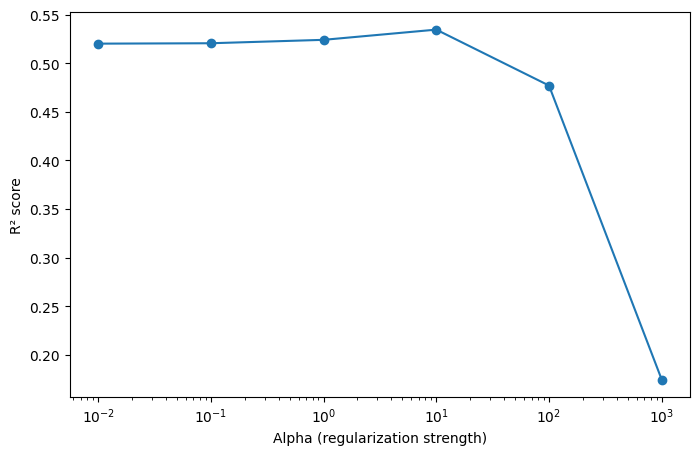

In [74]:
plt.figure(figsize=(8,5))
plt.plot(alphas, r2_scores, marker='o')
plt.xscale('log')
plt.xlabel("Alpha (regularization strength)")
plt.ylabel("R² score")
plt.show()

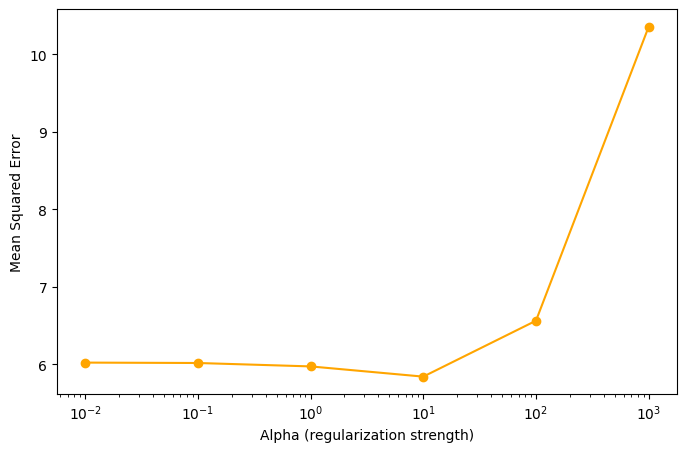

In [75]:
plt.figure(figsize=(8,5))
plt.plot(alphas, mses, marker='o', color='orange')
plt.xscale('log')
plt.xlabel("Alpha (regularization strength)")
plt.ylabel("Mean Squared Error")
plt.show()

Ridge performs slightly better then Linear regression (lower MSE and a bit higher $R^2$). It helps stabilize coefficients a little without hurting accuracy.

The Ridge regression achieves the best performance for small α values (≈ 0.01–1), balancing regularization and accuracy.
Increasing α beyond this range leads to over-regularization, reducing model flexibility and predictive performance.
Therefore, mild regularization improves stability without sacrificing accuracy, but excessive penalization causes significant underfitting.

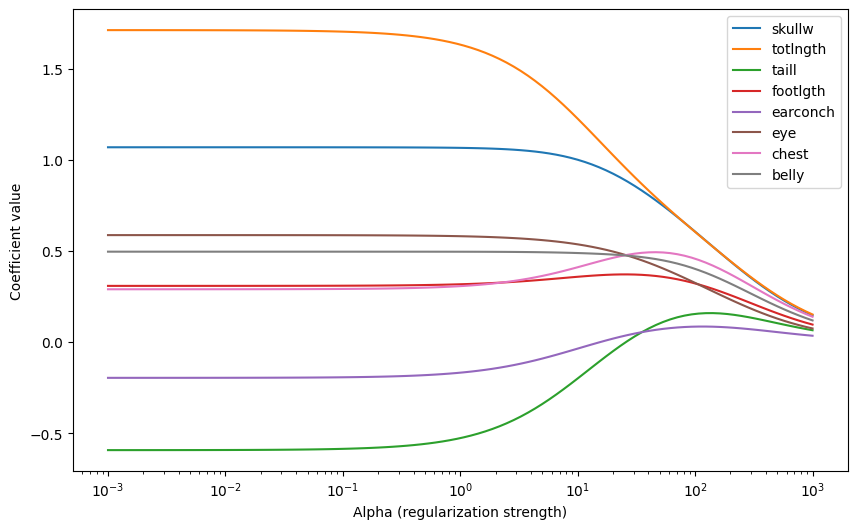

In [76]:
alphas = np.logspace(-3, 3, 100)
coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    coefs.append(ridge.coef_)

plt.figure(figsize=(10,6))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel("Alpha (regularization strength)")
plt.ylabel("Coefficient value")
plt.legend(body_dimensions2, loc='upper right')
plt.show()

The Ridge coefficient path plot demonstrates how increasing α gradually reduces the magnitude of all coefficients without setting any of them exactly to zero.
Unlike Lasso, which eliminates weak predictors, Ridge keeps all features active but reduces their impact proportionally.

### Lasso regression

In [77]:

X = possum_df[body_dimensions2].values
y = possum_df['hdlngth'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=44)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = [0.001, 0.01, 0.1, 0.5, 1, 10]

r2_scores = []
mses = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    r2_scores.append(r2)
    mses.append(mse)
    
    print(f"alpha={a:<6} | R²={r2:.3f} | MSE={mse:.3f}")

alpha=0.001  | R²=0.520 | MSE=6.016
alpha=0.01   | R²=0.525 | MSE=5.964
alpha=0.1    | R²=0.544 | MSE=5.715
alpha=0.5    | R²=0.550 | MSE=5.652
alpha=1      | R²=0.473 | MSE=6.607
alpha=10     | R²=-0.006 | MSE=12.627


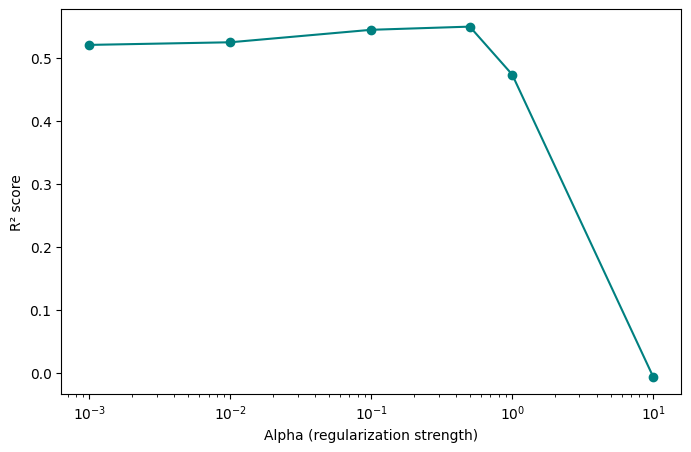

In [78]:
plt.figure(figsize=(8,5))
plt.plot(alphas, r2_scores, marker='o', color='teal')
plt.xscale('log')
plt.xlabel("Alpha (regularization strength)")
plt.ylabel("R² score")
plt.show()

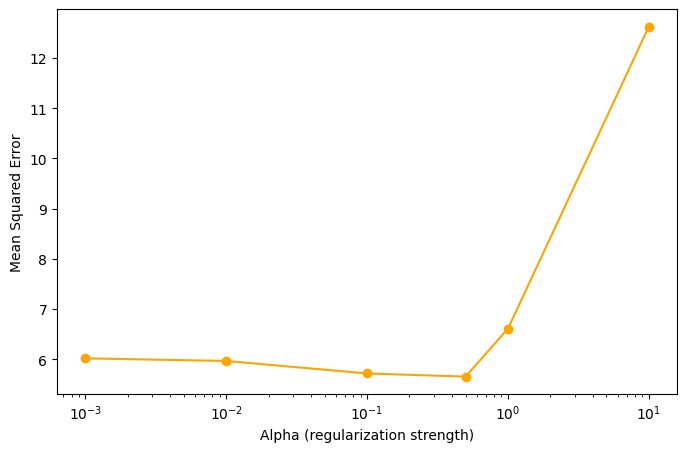

In [79]:
plt.figure(figsize=(8,5))
plt.plot(alphas, mses, marker='o', color='orange')
plt.xscale('log')
plt.xlabel("Alpha (regularization strength)")
plt.ylabel("Mean Squared Error")
plt.show()

Lasso regression performs best for small regularization strengths (α ≈ 0.01–0.1), where it maintains good predictive accuracy while slightly simplifying the model.
Increasing α too much forces many coefficients to zero, resulting in severe underfitting.
Compared to Ridge, Lasso is more aggressive, it not only shrinks coefficients but can eliminate variables entirely, making it valuable for feature selection but sensitive to over-penalization.

### Lasso Coefficient Shrinkage Plot

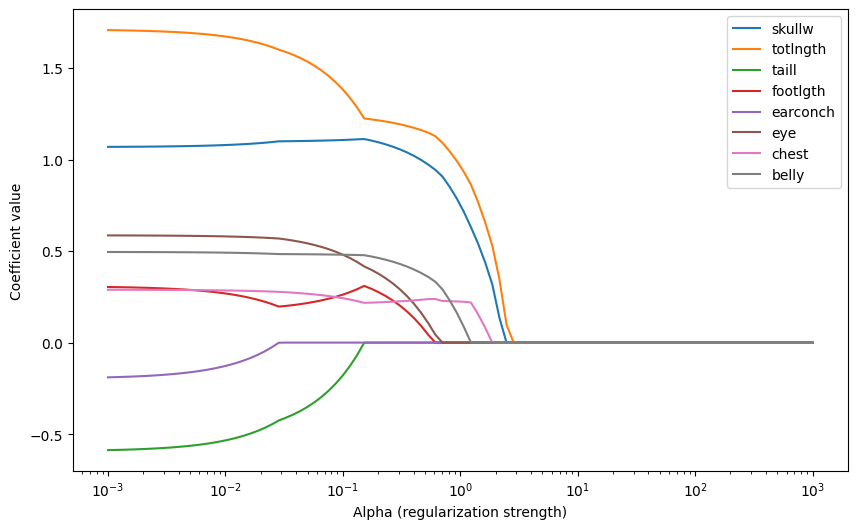

In [80]:
alphas = np.logspace(-3, 3, 100) 
coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    coefs.append(lasso.coef_)

plt.figure(figsize=(10,6))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel("Alpha (regularization strength)")
plt.ylabel("Coefficient value")
plt.legend(body_dimensions2, loc='upper right')
plt.show()

The coefficient path plot clearly shows that Lasso progressively eliminates less informative variables as α increases.
For small α, all features contribute; for large α, only the most important predictors remain (skull width and chest).

## Allometric regression 

Although its name suggests otherwise, logistic regression is not actually a regression method but a classification algorithm.
It predicts the probability that a given input belongs to a specific class.
Logistic regression is commonly used for binary classification, where the output can take one of two possible categories — for example, male/female (1/0) in our case.

### Head length vs total length

R²: 0.3410963033987875
MSE: 0.0014539274531665007
Intercept (b): 0.13756255034896459
Coefficient (a): 0.9567474282358573


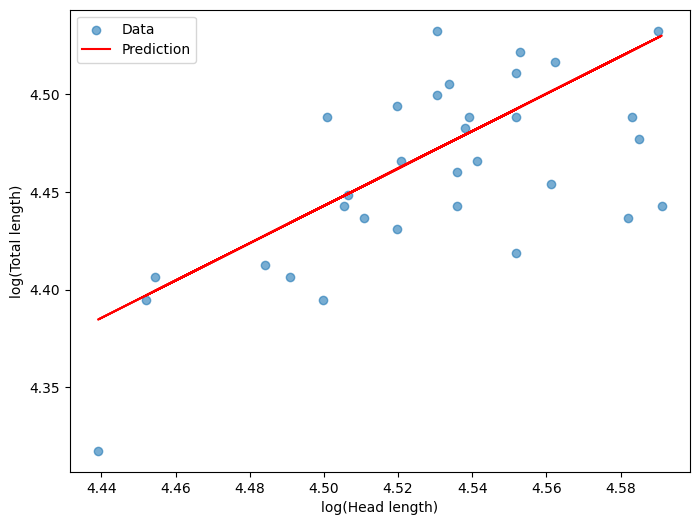

In [81]:
X = np.log(possum_df['hdlngth'].values).reshape(-1, 1)
y = np.log(possum_df['totlngth'].values)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=44)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = model.score(X_test, y_test)
mse = mean_squared_error(y_test, y_pred)
print("R²:", r2)
print("MSE:", mse)
print("Intercept (b):", model.intercept_)
print("Coefficient (a):", model.coef_[0])


plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, label="Data", alpha=0.6)
plt.plot(X_test, y_pred, color='red', label="Prediction")
plt.xlabel("log(Head length)")
plt.ylabel("log(Total length)")
plt.legend()
plt.show()

The plot shows an allometric relationship between the logarithm of head length and the logarithm of total body length in possums.
Each blue point represents an individual data sample, while the red line represents the fitted allometric regression model.

The positive slope indicates that as head length increases, total body length also tends to increase.
The approximately linear pattern on the log–log scale suggests that the relationship follows a power-law pattern, where total length scales with head length according to an allometric equation $y=ax^b$.

However, the slightly sublinear slope suggests weak negative allometry — larger possums have proportionally shorter heads relative to their body size.
Overall, head length is a reasonable but not perfect predictor of total body length.